In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import os
from pathlib import Path
import scipy
from scipy import stats
from scipy.stats import pearsonr, spearmanr

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [27]:
df_diario= pd.read_parquet('../data/processed/tablon_analitico_diario.parquet')
df_generacion= pd.read_parquet('../data/processed/tablon_analitico_generacion.parquet')
df_atmosferico= pd.read_parquet('../data/processed/tablon_analitico_atmosferico.parquet')

## Análisis de Irradiacion y Temperatura en plantas 1 y 2
- Los análisis van a realizarse de forma ordenada según el propio ciclo de generación de energía solar fotovoltaica: captación > Potencia DC > Potencia AC y Energia total generada.

In [28]:
#Datasets temporales para heatmaps de irradiacion y temperatura por horas planta 1 y 2

temp_hora_irradiacion = df_atmosferico.pivot_table(
    index='hora',
    columns='id_planta',
    values='irradiacion_wh_m2',
    aggfunc='sum'
)
temp_hora_temperatura = df_atmosferico.pivot_table(
    index='hora',
    columns='id_planta',
    values='temperatura_modulo_c',
    aggfunc='mean'
)

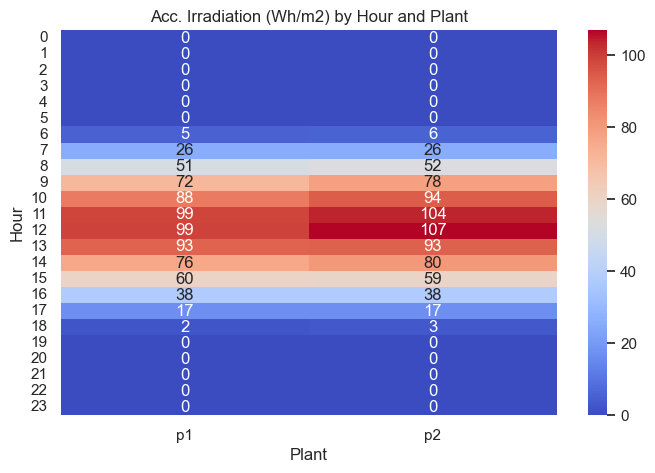

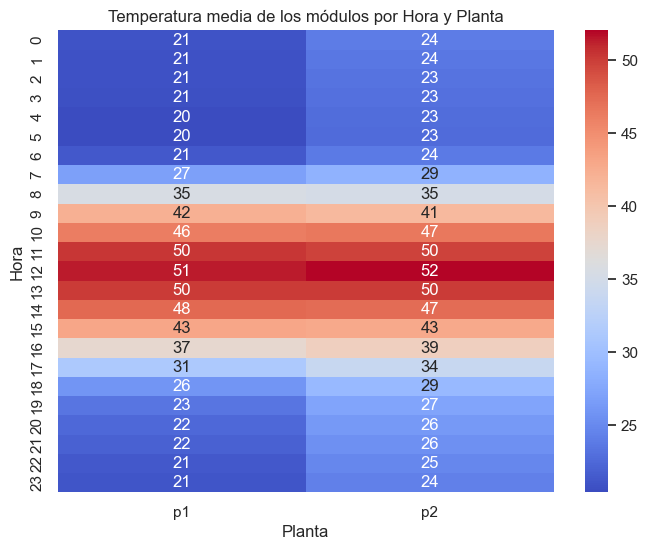

In [29]:
#Heatmap de Irradiacion acumulada en plantas 1 y 2 por hora
plt.figure(figsize=(8, 5))
sns.heatmap(temp_hora_irradiacion, annot=True, fmt=".0f", cmap="coolwarm")
plt.title("Acc. Irradiation (Wh/m2) by Hour and Plant")
plt.xlabel("Plant")
plt.ylabel("Hour")
plt.show()

#Heatmap de temperatura media por hora y planta
plt.figure(figsize=(8,6))
sns.heatmap(temp_hora_temperatura, annot=True, fmt=".0f", cmap="coolwarm")
plt.title("Temperatura media de los módulos por Hora y Planta")
plt.xlabel("Planta")
plt.ylabel("Hora")
plt.show()

- Por ahora **no se detectan anomalías** en valores de irradiacion acumulada y temperatura media horaria para ambas plantas. A continuación se realizará un **analisis por fecha, hora y planta para detectar posibles gaps y anomalías de medición.**

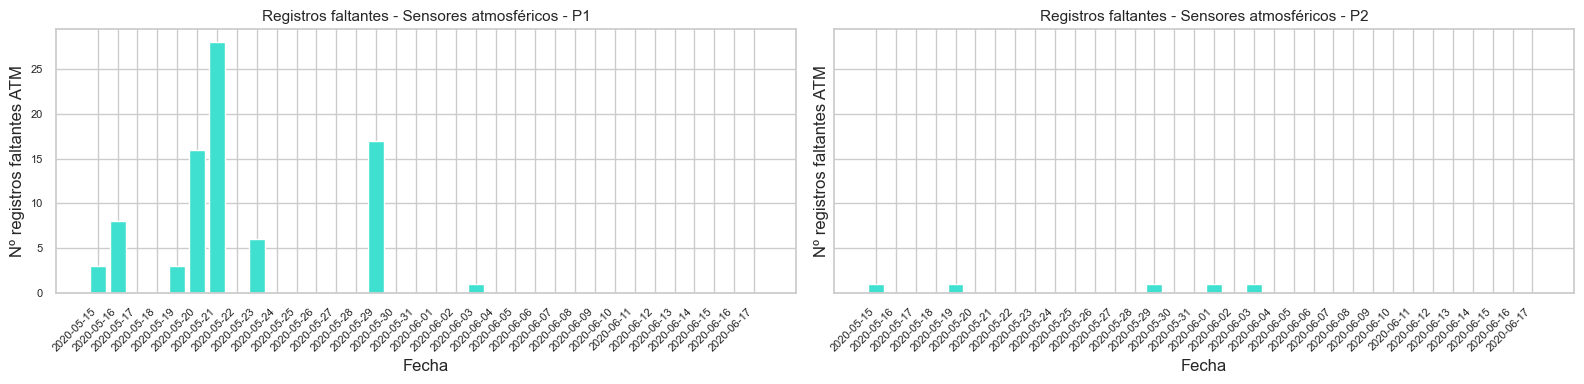

In [30]:
# Visualización de registros faltantes ATM por día y planta
fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharey=True)

for ax, planta in zip(axes, ["p1", "p2"]):

    df_planta = (
        df_diario[df_diario["id_planta"].str.lower() == planta]
        .drop_duplicates(subset=["id_planta", "fecha"])
        .sort_values("fecha")
        .copy()
    )
    x = np.arange(len(df_planta))

    ax.bar(x, df_planta["reg_faltantes_atm"], color="turquoise")

    ax.set_xticks(x)
    ax.set_xticklabels(df_planta["fecha"].dt.strftime("%Y-%m-%d"), rotation=45, ha="right", fontsize=8)
    ax.set_title(f"Registros faltantes - Sensores atmosféricos - {planta.upper()}", fontsize=11)
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Nº registros faltantes ATM")
    ax.tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.show()

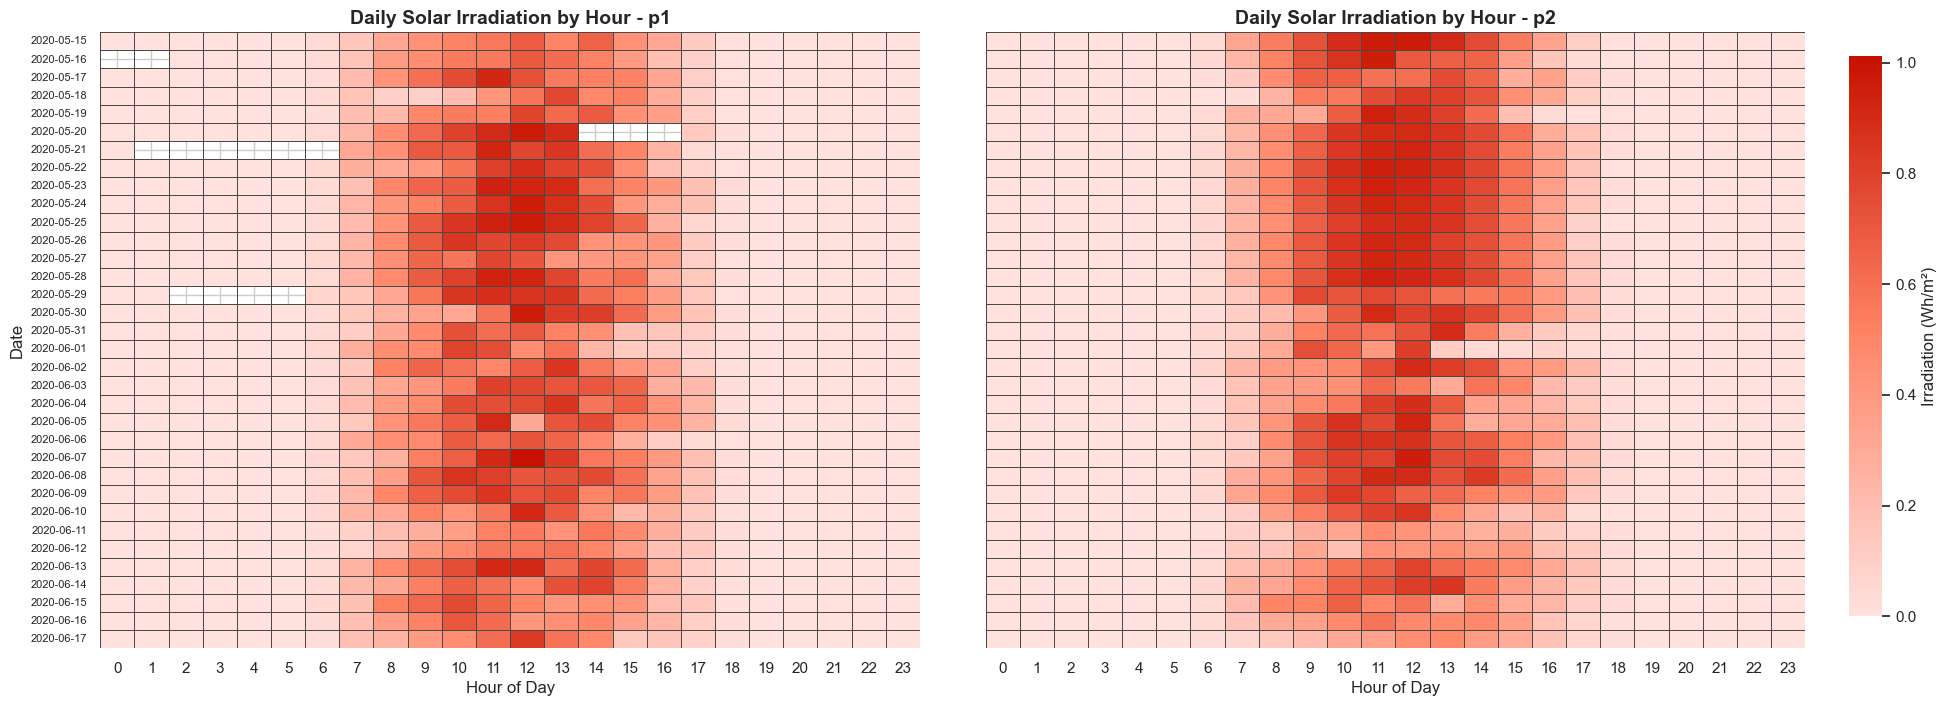

In [31]:
# Heatmap diario-horario de irradiacion por planta
from matplotlib.colors import LinearSegmentedColormap

df_irr = (
    df_atmosferico
    .groupby(["id_planta", "fecha", "hora"], as_index=False)["irradiacion_wh_m2"]
    .mean()
)

irr_cmap = LinearSegmentedColormap.from_list(
    "soft_beige_red",
    ["#ffe1de", "#ff8567", "#c71100"]
)

plants = sorted(df_irr["id_planta"].unique())
fechas = pd.Index(sorted(df_irr["fecha"].unique()))
horas = range(24)
vmax_irr = df_irr["irradiacion_wh_m2"].max()

fig, axes = plt.subplots(
    1, 2,
    figsize=(22, 8),
    sharey=True,
    gridspec_kw={"width_ratios": [1, 1]}
)

cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])

for i, (ax, plant) in enumerate(zip(axes, plants)):
    data = df_irr[df_irr["id_planta"].eq(plant)]

    heatmap_data = (
        data.pivot(index="fecha", columns="hora", values="irradiacion_wh_m2")
            .reindex(index=fechas, columns=horas)
    )

    sns.heatmap(
        heatmap_data,
        ax=ax,
        cmap=irr_cmap,
        vmin=0,
        vmax=vmax_irr,
        mask=False,
        linewidths=0.45,
        linecolor="#494949",
        cbar=i == len(plants) - 1,
        cbar_ax=cbar_ax if i == len(plants) - 1 else None,
        cbar_kws={"label": "Irradiation (Wh/m²)"}
    )

    ax.set_title(f"Daily Solar Irradiation by Hour - {plant}", fontsize=14, fontweight="bold")
    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("Date" if i == 0 else "")
    ax.tick_params(axis="x", rotation=0)

    ax.set_yticks(np.arange(len(fechas)) + 0.5)
    ax.set_yticklabels(
        [pd.Timestamp(d).strftime("%Y-%m-%d") for d in fechas],
        rotation=0,
        fontsize=8
    )

plt.subplots_adjust(right=0.9, wspace=0.08)
plt.show()

In [32]:
#Comprovación de horas con nula/mínima irradiación
df_media = (
    df_atmosferico
    .groupby(["id_planta", "hora"], as_index=False)["irradiacion_wh_m2"]
    .mean()
)
horas_sin_irradiacion = (
    df_media[df_media["irradiacion_wh_m2"] <= 0.01]
    .groupby("id_planta")["hora"]
    .agg(list)
)
print(horas_sin_irradiacion)

id_planta
p1    [0, 1, 2, 3, 4, 5, 19, 20, 21, 22, 23]
p2    [0, 1, 2, 3, 4, 5, 19, 20, 21, 22, 23]
Name: hora, dtype: object


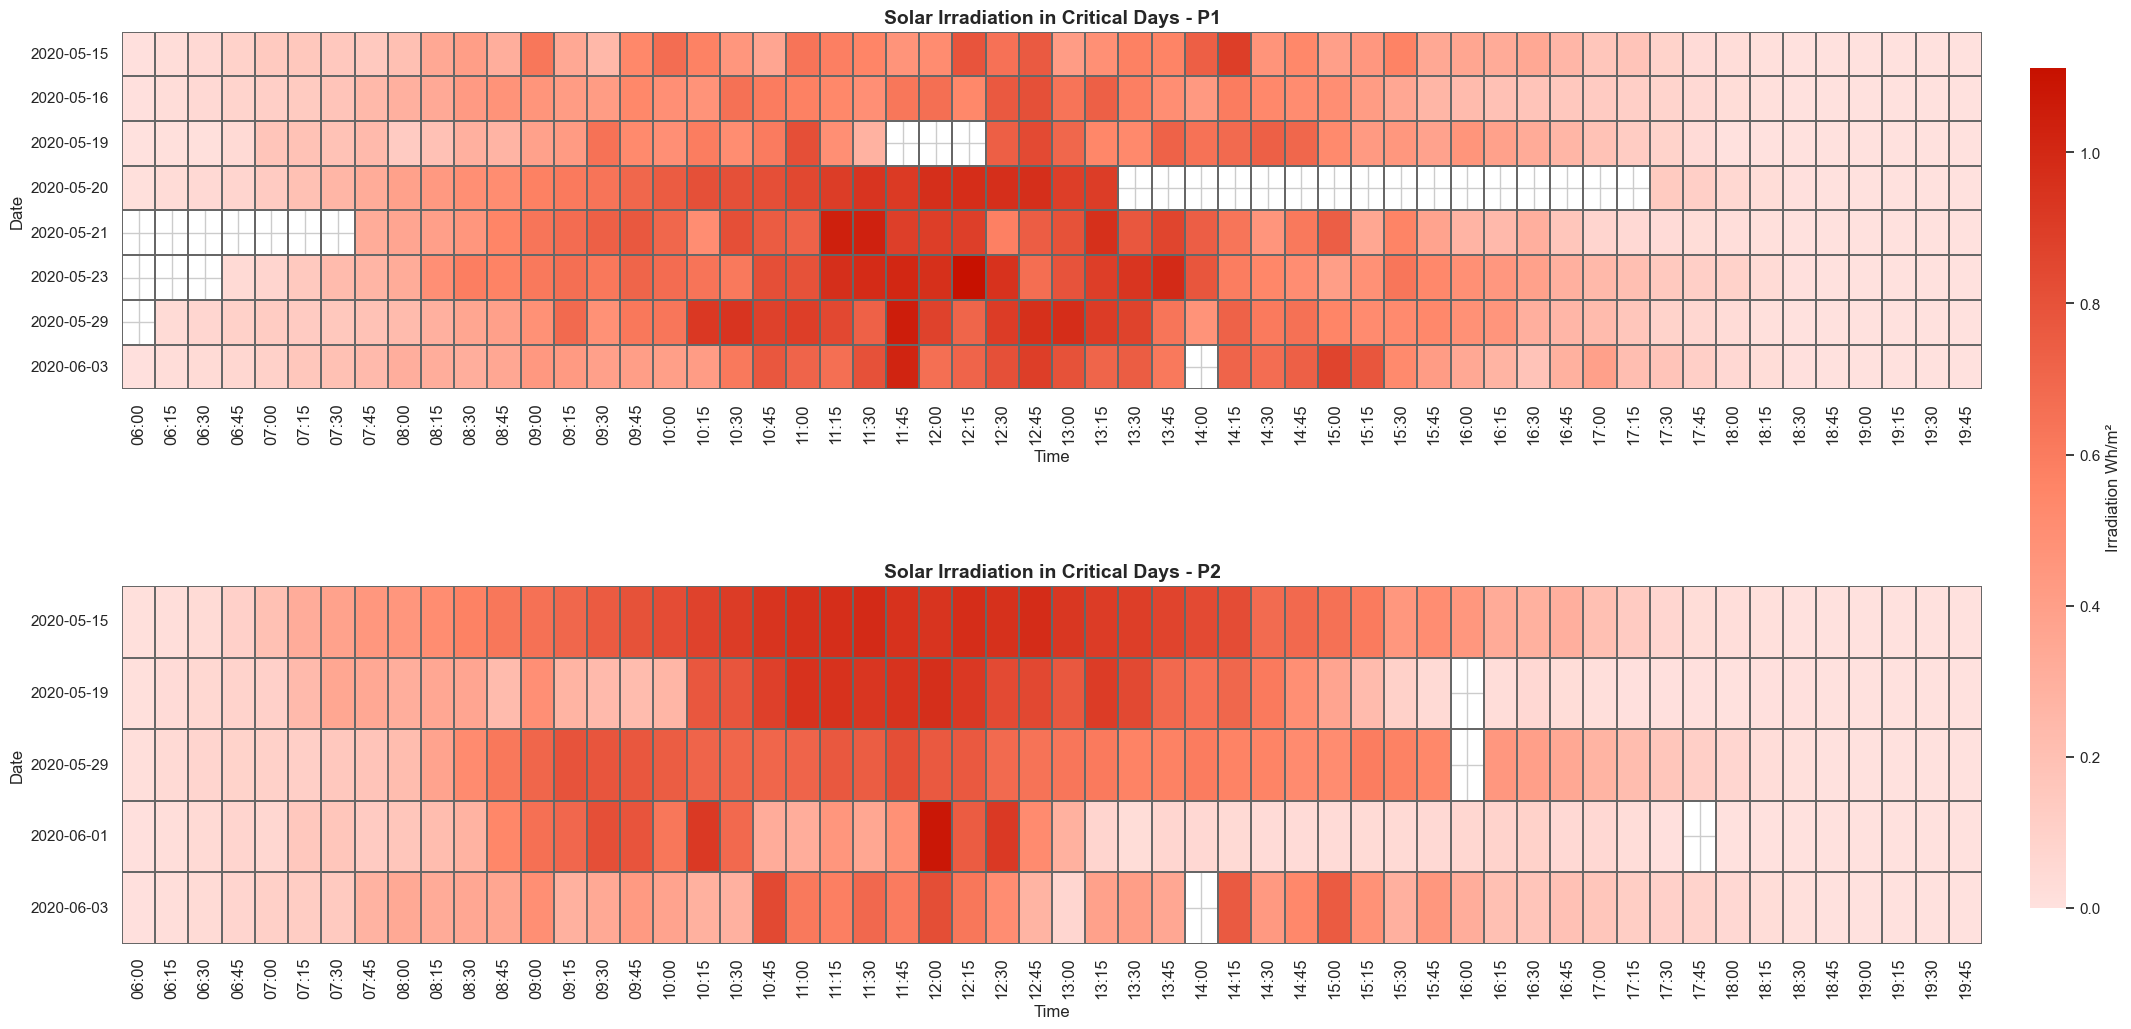

In [33]:
# Combinaciones (día, planta) que quieres representar
seleccion_dias_criticos = [
    (pd.Timestamp("2020-05-15"), "p1"),
    (pd.Timestamp("2020-05-16"), "p1"),
    (pd.Timestamp("2020-05-19"), "p1"),
    (pd.Timestamp("2020-05-20"), "p1"),
    (pd.Timestamp("2020-05-21"), "p1"),
    (pd.Timestamp("2020-05-23"), "p1"),
    (pd.Timestamp("2020-05-29"), "p1"),
    (pd.Timestamp("2020-06-03"), "p1"),
    (pd.Timestamp("2020-05-15"), "p2"),
    (pd.Timestamp("2020-05-19"), "p2"),
    (pd.Timestamp("2020-05-29"), "p2"),
    (pd.Timestamp("2020-06-01"), "p2"),
    (pd.Timestamp("2020-06-03"), "p2"),
]

from matplotlib.colors import LinearSegmentedColormap

#mapa de colores
irr_cmap = LinearSegmentedColormap.from_list("soft_beige_red", ["#ffe1de", "#ff8567", "#c71100"])

#dataset temporal
df_plot = df_atmosferico.copy()
df_plot["fecha_hora"] = pd.to_datetime(df_plot["fecha_hora"])
df_plot["fecha"] = df_plot["fecha_hora"].dt.normalize()
df_plot["hora_15min"] = df_plot["fecha_hora"].dt.strftime("%H:%M")

seleccion = pd.DataFrame(seleccion_dias_criticos, columns=["fecha", "id_planta"])
df_plot = df_plot.merge(seleccion, on=["fecha", "id_planta"], how="inner")

#Intervalo horario productivo
horas_15min = pd.date_range("06:00", "19:45", freq="15min").strftime("%H:%M")

#variables para ejes
plants = ["p1", "p2"]
vmax_irr = df_plot["irradiacion_wh_m2"].max()

#heatmap config
fig, axes = plt.subplots(2, 1, figsize=(24, 12), sharex=False)
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])

for i, (ax, plant) in enumerate(zip(axes, plants)):

    fechas_planta = [
        fecha
        for fecha, planta in seleccion_dias_criticos
        if planta == plant
    ]

    heatmap_data = (
        df_plot[df_plot["id_planta"].eq(plant)]
        .pivot_table(
            index="fecha",
            columns="hora_15min",
            values="irradiacion_wh_m2",
            aggfunc="mean"
        )
        .reindex(
            index=fechas_planta,
            columns=horas_15min
        )
    )

    sns.heatmap(
        heatmap_data,
        ax=ax,
        cmap=irr_cmap,
        vmin=0,
        vmax=vmax_irr,
        linewidths=0.25,
        linecolor="#676767",
        cbar=i == 1,
        cbar_ax=cbar_ax if i == 1 else None,
        cbar_kws={"label": "Irradiation Wh/m²"}
    )

    ax.set_title(
        f"Solar Irradiation in Critical Days - {plant.upper()}",
        fontsize=14,
        fontweight="bold"
    )
    ax.set_xlabel("Time")
    ax.set_ylabel("Date")

    ax.set_yticklabels([fecha.strftime("%Y-%m-%d") for fecha in fechas_planta], rotation=0)

    # Todos los timestamps en ambos gráficos
    ax.set_xticks(np.arange(len(horas_15min)) + 0.5)
    ax.set_xticklabels(horas_15min, rotation=90, ha="center", fontsize=12)
    ax.tick_params(axis="x", labelbottom=True)

plt.subplots_adjust(right=0.9, hspace=0.55, bottom=0.12)

plt.show()

#### Insight 1: Ausencia de registros en período de captación en planta 1

Se ha identificado **ausencia de registros durante intervalo de captación** (6h a 20h) en la **planta 1:**
- Dias e intervalos con ausencia de registros:
    1.  2020-05-19: 11:45, 12:00 y 12:45 (3 registros - alta irradiación).
    2. 2020-05-20: 13:30 a 17:15 (16 registros - alta irradiación).
    3. 2020-05-21: 06:00 a 07:30 (7 registros - baja irradiación // 21 registros - nula irradiación).
    4. 2020-05-23: 06:00 a 06:30 (3 registros - baja irradiación // 3 registros - nula irradiación).

## Performance Ratio: Energia generada/Irradiación
- Se va a analizar la energia generada diaria contra la irradiación acumulada diaria para detectar posibles anomalías.

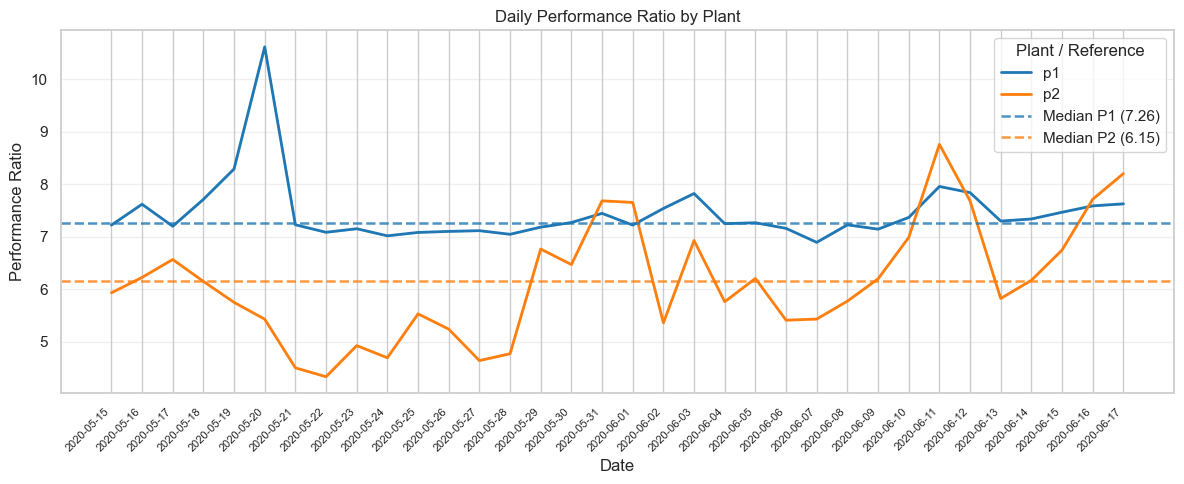

In [34]:
# Mediana del PR por planta
pr_mediana = (df_diario.groupby("id_planta")["performance_ratio"].median())

# Una fila por fecha para obtener las etiquetas del eje X
fechas = (df_diario[["fecha"]].drop_duplicates().sort_values("fecha").reset_index(drop=True))
fechas["x"] = range(len(fechas))

# Añadimos la posición x al dataframe
d = (df_diario.merge(fechas, on="fecha").sort_values(["id_planta", "fecha"]))

plt.figure(figsize=(12, 5))
ax = plt.gca()
sns.lineplot(data=d,x="x",y="performance_ratio",hue="id_planta",palette=["tab:blue", "tab:orange"],linewidth=2, ax=ax)

# Medianas
ax.axhline(pr_mediana["p1"],color="tab:blue",linestyle="--",linewidth=1.8,label=f"Median P1 ({pr_mediana['p1']:.2f})",alpha=0.8)
ax.axhline(pr_mediana["p2"],color="tab:orange",linestyle="--",linewidth=1.8,label=f"Median P2 ({pr_mediana['p2']:.2f})",alpha=0.8)

# Mostrar todos los días
ax.set_xticks(fechas["x"])
ax.set_xticklabels(fechas["fecha"].dt.strftime("%Y-%m-%d"),rotation=45,ha="right",fontsize=8)

ax.set_title("Daily Performance Ratio by Plant")
ax.set_xlabel("Date")
ax.set_ylabel("Performance Ratio")
ax.grid(axis="y", alpha=0.3)

ax.legend(title="Plant / Reference")

plt.tight_layout()
plt.show()

#### Insight 1.2 - Correlación entre PR anómalo y anomalías de captación en planta 1
Se ha identificado correlación visible entre días con PR elevado y días con ausencia de registros en intervalos de alta captación.
- Días destacados: 18 y 20 Mayo.

## Irradiacion VS potencia DC
- Se va a hacer un análisis de Irradiación VS Potencia DC para detectar posibles anomalías y descorrelaciones.

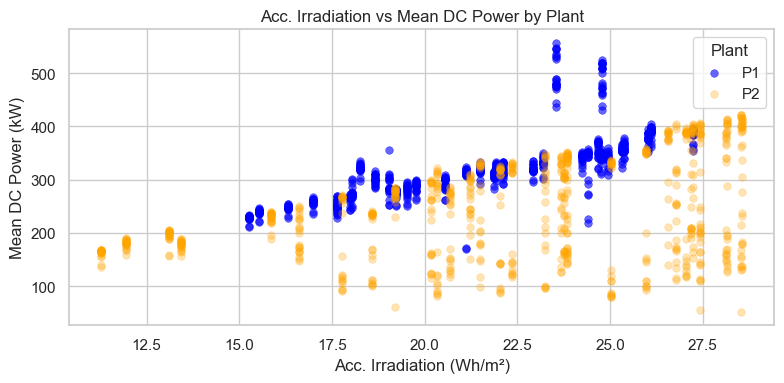

In [35]:
# Scatter superpuesto entre irradiacion y potencia DC por planta

colors = {"p1": "blue", "p2": "orange"}
alphas = {"p1": 0.6, "p2": 0.3}

plt.figure(figsize=(8, 4))

for plant in ["p1", "p2"]:
    data_plant = df_diario[df_diario["id_planta"] == plant]

    sns.scatterplot(
        data=data_plant,
        x="irradiacion_total_diaria",
        y="potencia_dc_kw_media",
        color=colors[plant],
        alpha=alphas[plant],
        label=plant.upper(),
        s=30,
        edgecolor=None
    )

plt.legend(title="Plant")
plt.xlabel("Acc. Irradiation (Wh/m²)")
plt.ylabel("Mean DC Power (kW)")
plt.title("Acc. Irradiation vs Mean DC Power by Plant")
plt.tight_layout()
plt.show()

#### Insight 1.3 - Descorrelación severa entre Potencia DC e Irradiación en planta 2 y moderada en planta 1
- En planta 2 se observa una **descorrelacion severa entre Irradiación y Potencia DC**. Se analizará la **correlación entre Potencia DC y AC** para comprovar si existe problema en la **transformación de potencia** en puntos anómalos.
- En planta 1 se observa descorrelación puntual en valores de irradiación elevados, mostrando Potencia DC superior a la esperada.

In [39]:
#Pearson y Spearman entre potencia DC y potencia AC en planta 2 solo en puntos anómalos
irradiacion_umbral = 16
potencia_umbral = 180

df_anomalos = df_diario[(df_diario['irradiacion_total_diaria'] >= irradiacion_umbral) &
                 (df_diario['potencia_dc_kw_media'] <= potencia_umbral)
].copy()

df_corr = df_anomalos[["potencia_dc_kw_media","potencia_ac_kw_media"]].dropna()

pearson_corr = df_corr["potencia_dc_kw_media"].corr(
    df_corr["potencia_ac_kw_media"],
    method="pearson"
)

spearman_corr = df_corr["potencia_dc_kw_media"].corr(
    df_corr["potencia_ac_kw_media"],
    method="spearman"
)

print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"Pearson strength 0-1: {abs(pearson_corr):.3f}")

print(f"Spearman correlation: {spearman_corr:.3f}")
print(f"Spearman strength 0-1: {abs(spearman_corr):.3f}")

Pearson correlation: 1.000
Pearson strength 0-1: 1.000
Spearman correlation: 1.000
Spearman strength 0-1: 1.000


#### Insight 2 - Anomalías de transformación de potencia DC/AC descartadas
Existe correlación entre Potencia DC y AC en valores anómalos, lo cual **descarta fallos en la transformación de Potencia**, aunque no se puede determinar aun el origen de las anomalías todavía.

## Analisis de Potencia de los inversores
Para el analisis de captacion de potencia de los inverters, lo dividiremos en tres partes:
1. Visualización de registros faltantes y relación Energia - Potencia AC para detectar anomalías a nivel diario.
2. Análisis por inversor para detectar anomalías en días específicos.
3. Análisis de registros anómalos especificos para sacar insights de valor.

#### Visualización de registros de generación faltantes (potencia + energia)

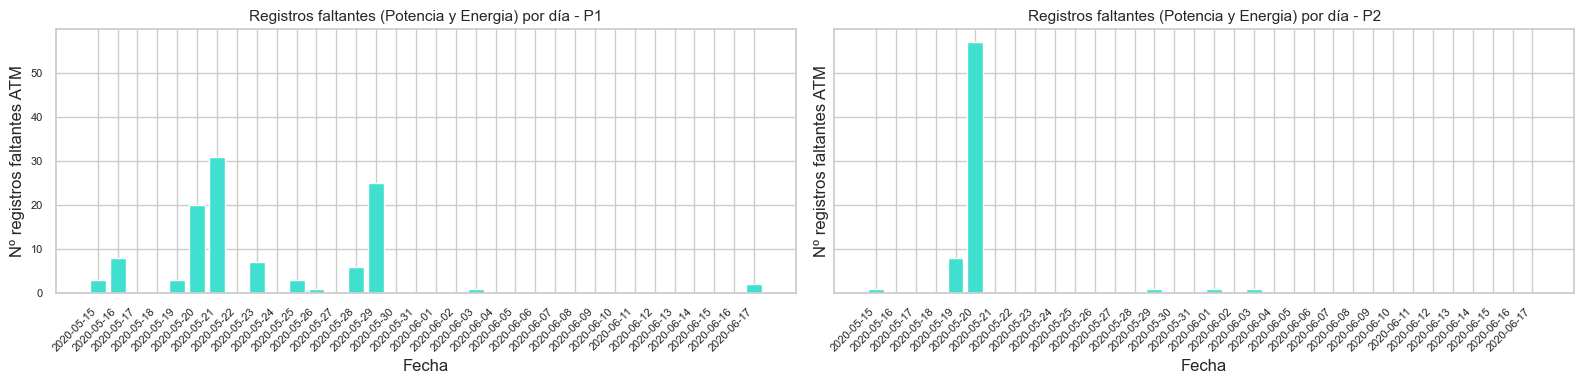

In [40]:
# Visualización de registros faltantes de Potencia por día y planta
fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharey=True)

for ax, planta in zip(axes, ["p1", "p2"]):

    df_planta = (
        df_diario[df_diario["id_planta"].str.lower() == planta]
        .drop_duplicates(subset=["id_planta", "fecha"])
        .sort_values("fecha")
        .copy()
    )
    x = np.arange(len(df_planta))

    ax.bar(x, df_planta["reg_faltantes_gen"], color="turquoise")

    ax.set_xticks(x)
    ax.set_xticklabels(df_planta["fecha"].dt.strftime("%Y-%m-%d"), rotation=45, ha="right", fontsize=8)
    ax.set_title(f"Registros faltantes (Potencia y Energia) por día - {planta.upper()}", fontsize=11)
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Nº registros faltantes ATM")
    ax.tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.show()

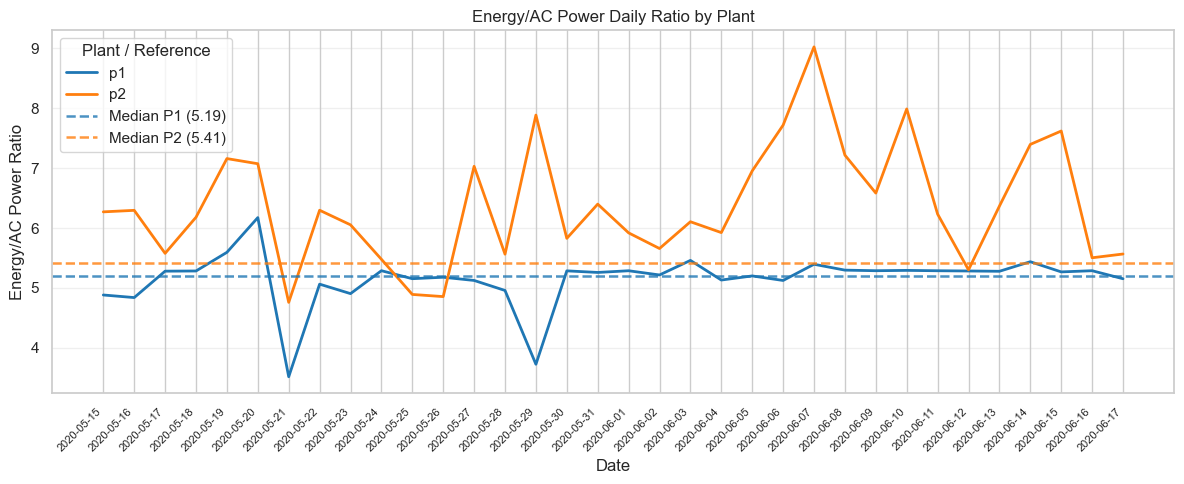

In [44]:
# Mediana de la Potencia DC por planta
mediana_ratio = (df_diario.groupby("id_planta")["ratio_potencia_ac_energia"].median())

# Una fila por fecha para obtener las etiquetas del eje X
fechas = (df_diario[["fecha"]].drop_duplicates().sort_values("fecha").reset_index(drop=True))
fechas["x"] = range(len(fechas))

# Añadimos la posición x al dataframe
d = (df_diario.merge(fechas, on="fecha").sort_values(["id_planta", "fecha"]))

plt.figure(figsize=(12, 5))
ax = plt.gca()
sns.lineplot(data=d,x="x",y="ratio_potencia_ac_energia",hue="id_planta",palette=["tab:blue", "tab:orange"],linewidth=2, ax=ax, errorbar=None)

# Medianas
ax.axhline(mediana_ratio["p1"],color="tab:blue",linestyle="--",linewidth=1.8,label=f"Median P1 ({mediana_ratio['p1']:.2f})",alpha=0.8)
ax.axhline(mediana_ratio["p2"],color="tab:orange",linestyle="--",linewidth=1.8,label=f"Median P2 ({mediana_ratio['p2']:.2f})",alpha=0.8)

# Mostrar todos los días
ax.set_xticks(fechas["x"])
ax.set_xticklabels(fechas["fecha"].dt.strftime("%Y-%m-%d"),rotation=45,ha="right",fontsize=8)

ax.set_title("Energy/AC Power Daily Ratio by Plant")
ax.set_xlabel("Date")
ax.set_ylabel("Energy/AC Power Ratio")
ax.grid(axis="y", alpha=0.3)

ax.legend(title="Plant / Reference")

plt.tight_layout()
plt.show()

Después de analizar visualizar ausencia de registros y la relación de Energia generada vs Potencia AC de los inversores, se ha seleccionado una combinación de días criticos basados en dos factores:
- Días con valores muy anómalos respecto a la mediana de la planta en la relación de Energia generada vs Potencia AC.
- Días con alta cantidad de registros faltantes.

Más adelante se hará un analisis mas profundo de los datos para cada tipo de anomalía.

### Análisis de potencia AC por inversor y hora en días con más anomalías

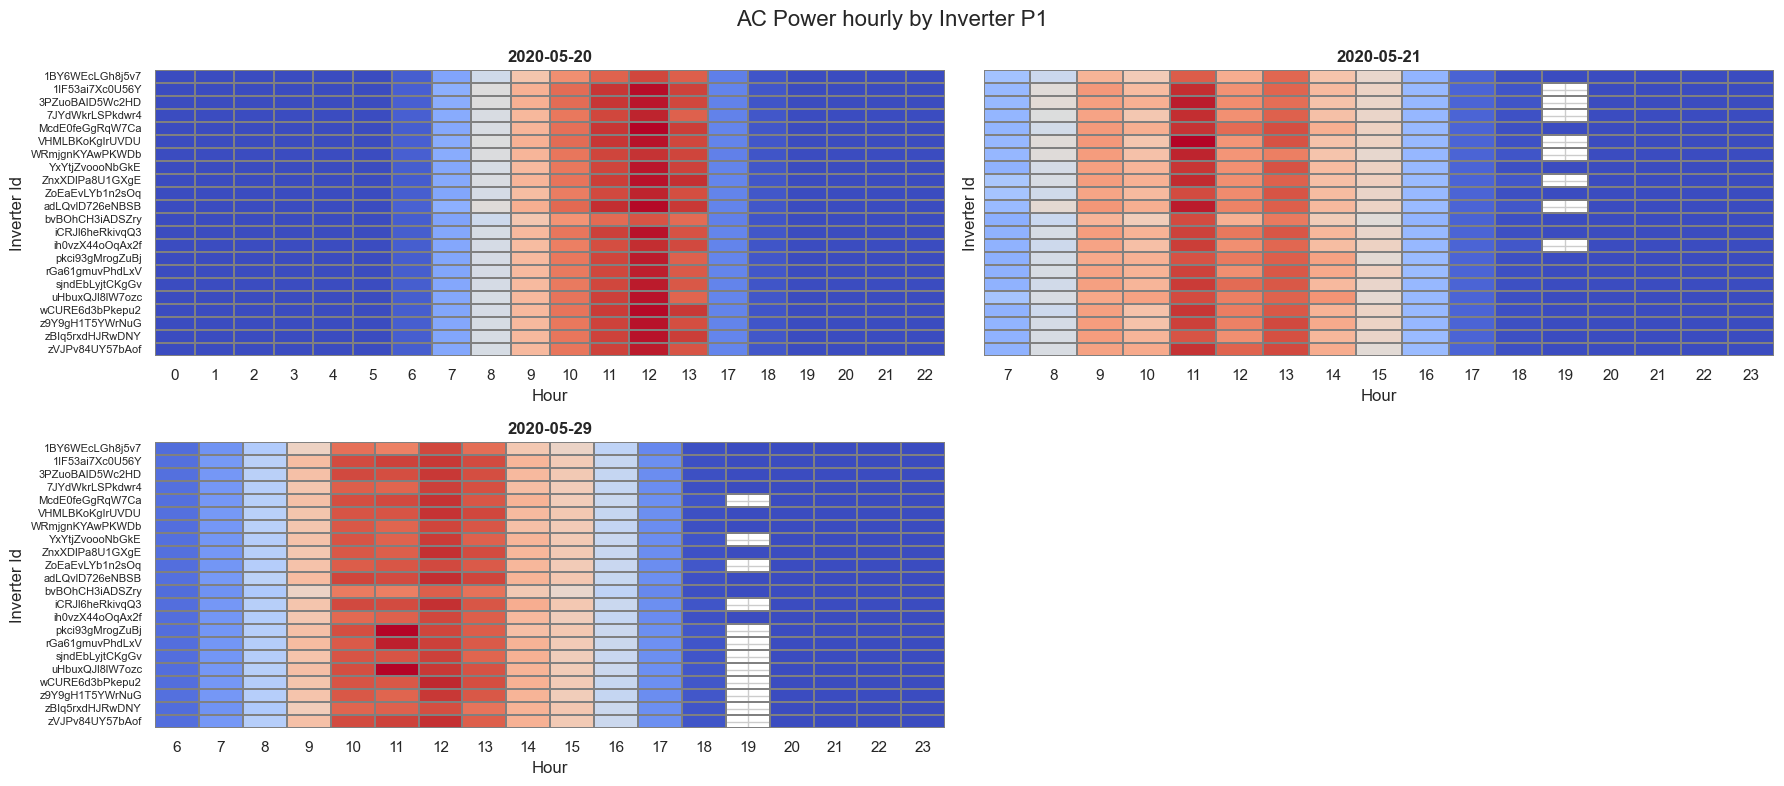

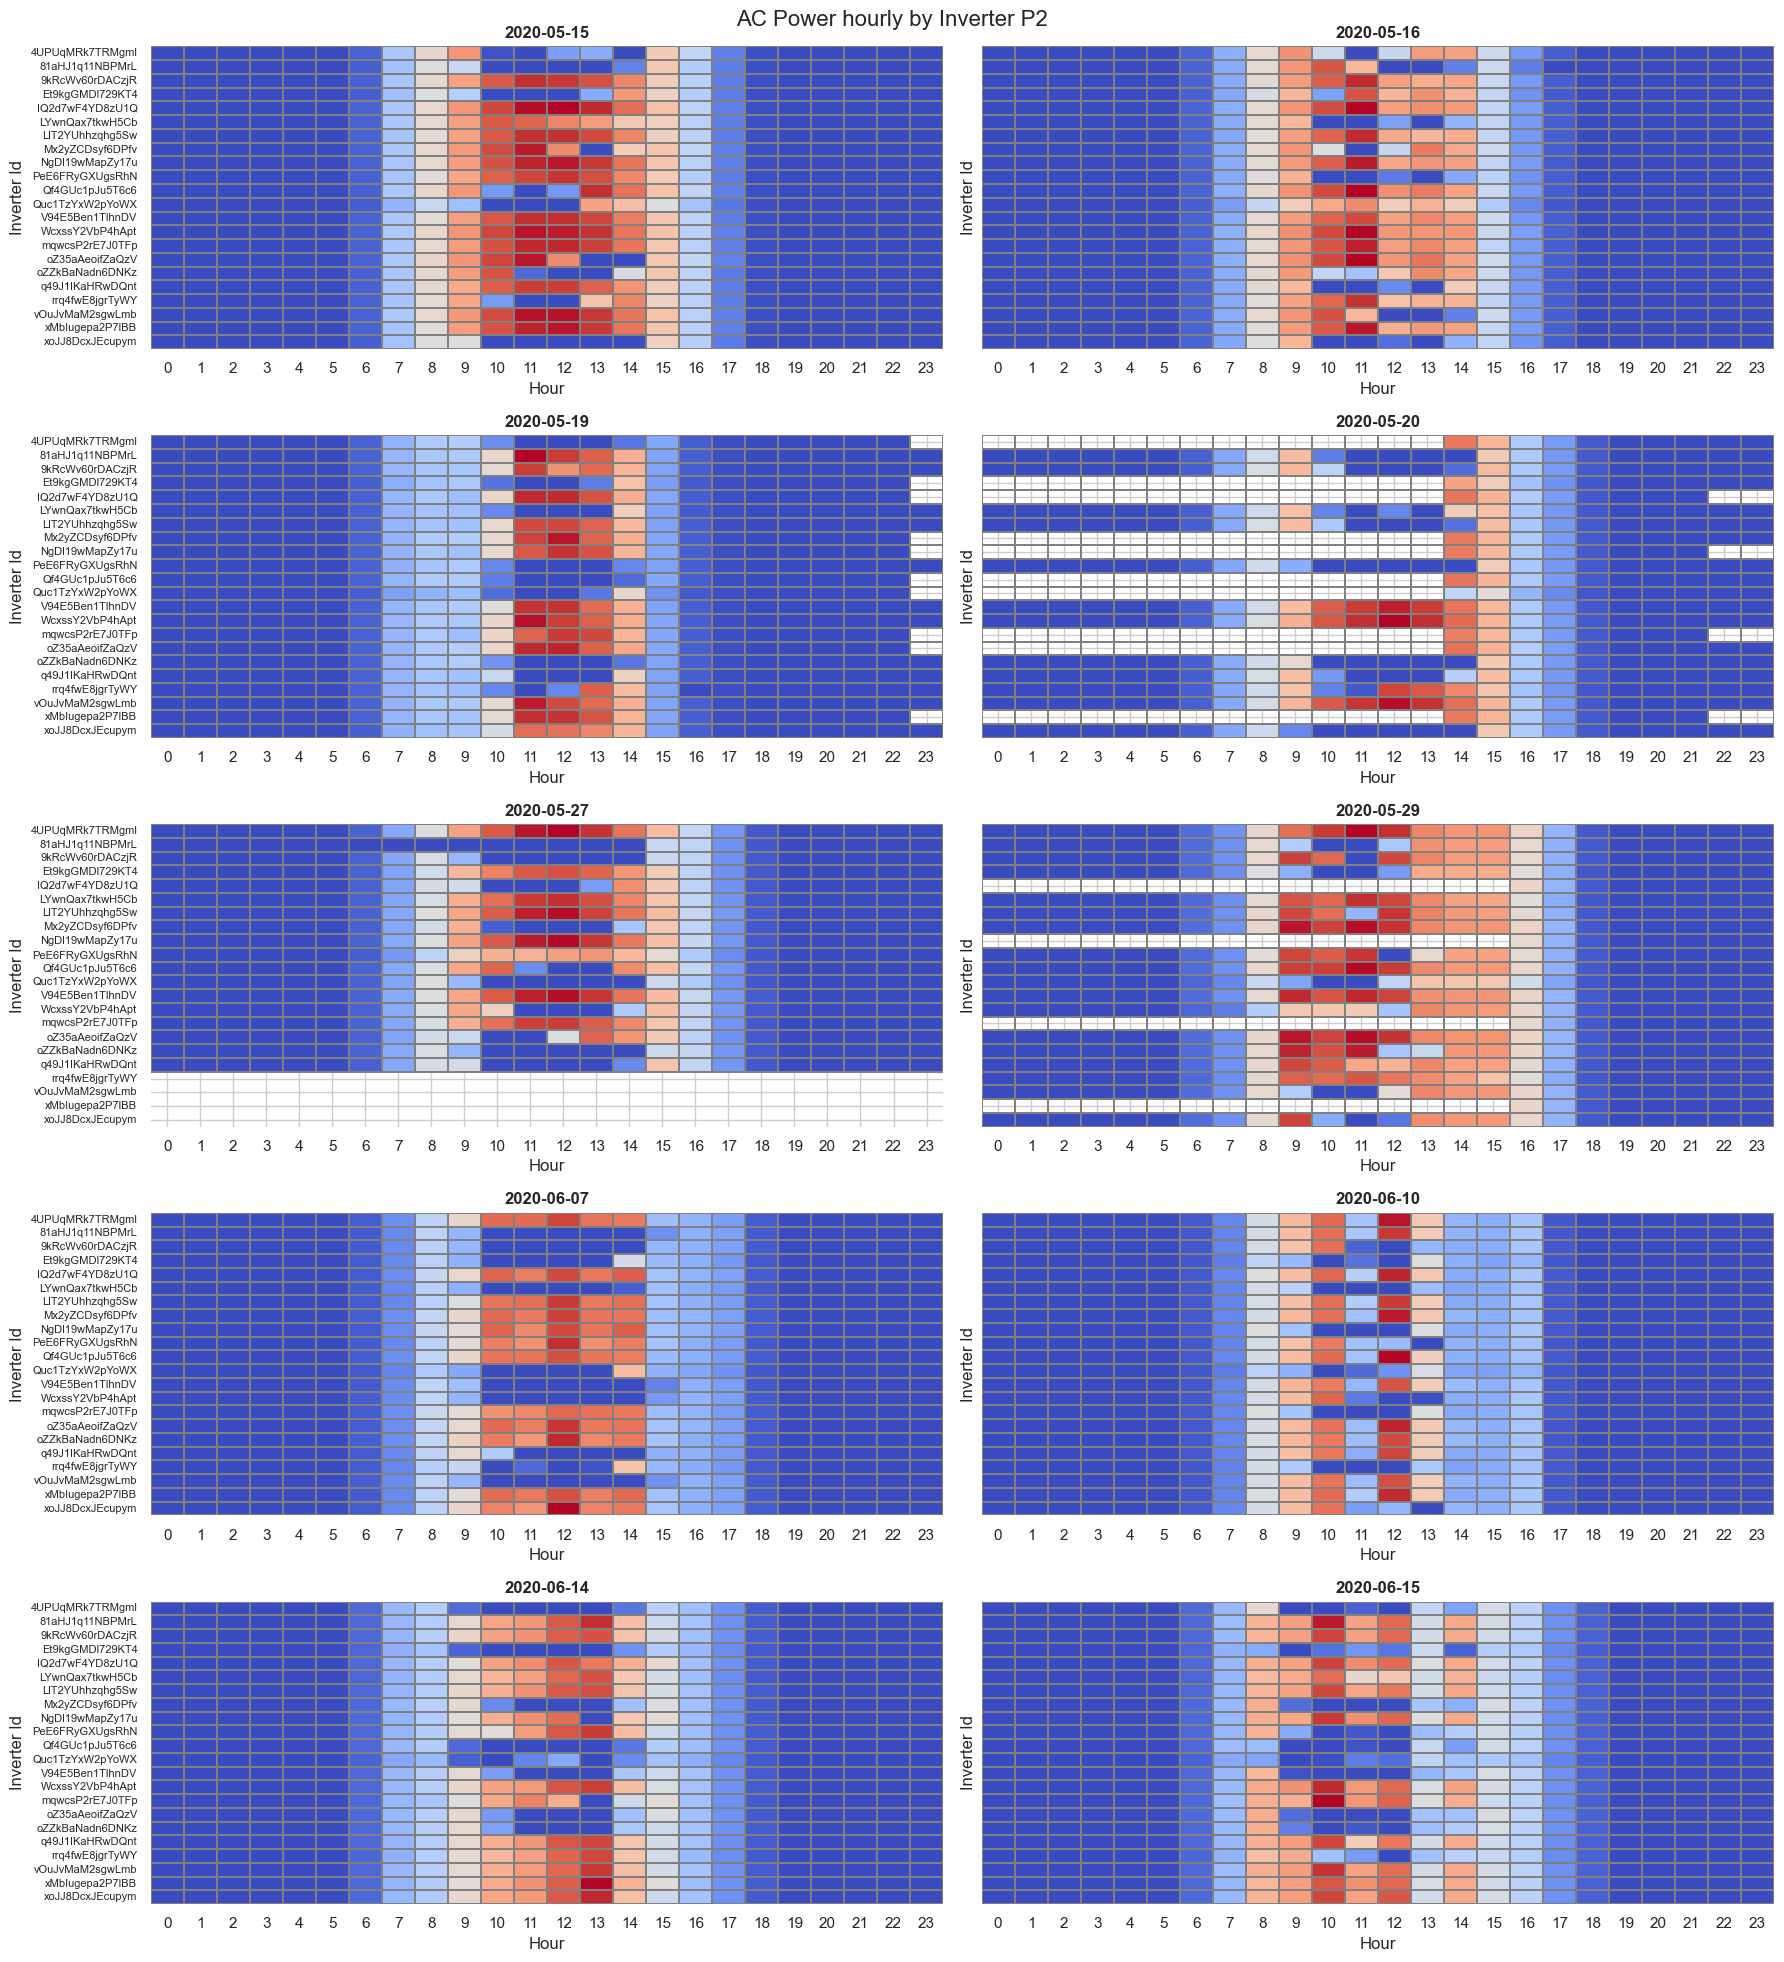

In [45]:
fechas_por_planta = {
    "p1": "05-20 05-21 05-29".split(),
    "p2": "05-15 05-16 05-19 05-20 05-27 05-29 06-07 06-10 06-14 06-15".split(),
}

dfp = (
    df_generacion.groupby(["id_planta", "fecha", "hora", "id_inversor"], as_index=False)
      ["potencia_ac_kw"].mean()
)

for planta, dias in fechas_por_planta.items():
    fechas = pd.to_datetime([f"2020-{d}" for d in dias])

    data = dfp[dfp["id_planta"].eq(planta) & dfp["fecha"].isin(fechas)]
    dias_unicos = sorted(data["fecha"].unique())

    fig, axes = plt.subplots(
        nrows=int(np.ceil(len(dias_unicos) / 2)),
        ncols=2,
        figsize=(18, 4 * int(np.ceil(len(dias_unicos) / 2))),
        sharey=True
    )

    axes = np.ravel(axes)

    for ax, dia in zip(axes, dias_unicos):
        pivot = data[data["fecha"].eq(dia)].pivot(
            index="id_inversor",
            columns="hora",
            values="potencia_ac_kw"
        )

        sns.heatmap(
            pivot,
            ax=ax,
            cmap="coolwarm",
            cbar=False,
            linewidths=0.3,
            linecolor="gray"
        )
        
        ax.set_yticks(np.arange(len(pivot.index)) + 0.5)
        ax.set_yticklabels(pivot.index.astype(str), rotation=0, fontsize=8)

        ax.set_title(pd.Timestamp(dia).strftime("%Y-%m-%d"), fontweight="bold")
        ax.set_xlabel("Hour")
        ax.set_ylabel("Inverter Id")
        ax.tick_params(axis="x", rotation=0)

    for ax in axes[len(dias_unicos):]:
        ax.axis("off")

    fig.suptitle(f"AC Power hourly by Inverter {planta.upper()}", fontsize=16)
    plt.tight_layout()
    plt.show()

### Insight 3 - Anomalías diversas en registros de inversores concretos a nivel horario
De entre los días observados, se muestran anomalías de diversos tipos, por ejemplo:
1. Planta 1. 2020-05-20. Faltan registros de todos los inversores en un rango horario de captación determinado.
2. Planta 2. 2020-05-15. Algunos inverters muestran registros con valores anómalos.
3. Planta 2. 2020-05-20. Algunos inverters muestran ausencia de registros en intervalos horarios determinados.

### Análisis de registros anómalos específicos dia-inversor

In [39]:
for planta, inversores in df_diario.groupby("id_planta")["id_inversor"]:
    print(planta, sorted(inversores.dropna().unique()))

p1 ['1BY6WEcLGh8j5v7', '1IF53ai7Xc0U56Y', '3PZuoBAID5Wc2HD', '7JYdWkrLSPkdwr4', 'McdE0feGgRqW7Ca', 'VHMLBKoKgIrUVDU', 'WRmjgnKYAwPKWDb', 'YxYtjZvoooNbGkE', 'ZnxXDlPa8U1GXgE', 'ZoEaEvLYb1n2sOq', 'adLQvlD726eNBSB', 'bvBOhCH3iADSZry', 'iCRJl6heRkivqQ3', 'ih0vzX44oOqAx2f', 'pkci93gMrogZuBj', 'rGa61gmuvPhdLxV', 'sjndEbLyjtCKgGv', 'uHbuxQJl8lW7ozc', 'wCURE6d3bPkepu2', 'z9Y9gH1T5YWrNuG', 'zBIq5rxdHJRwDNY', 'zVJPv84UY57bAof']
p2 ['4UPUqMRk7TRMgml', '81aHJ1q11NBPMrL', '9kRcWv60rDACzjR', 'Et9kgGMDl729KT4', 'IQ2d7wF4YD8zU1Q', 'LYwnQax7tkwH5Cb', 'LlT2YUhhzqhg5Sw', 'Mx2yZCDsyf6DPfv', 'NgDl19wMapZy17u', 'PeE6FRyGXUgsRhN', 'Qf4GUc1pJu5T6c6', 'Quc1TzYxW2pYoWX', 'V94E5Ben1TlhnDV', 'WcxssY2VbP4hApt', 'mqwcsP2rE7J0TFp', 'oZ35aAeoifZaQzV', 'oZZkBaNadn6DNKz', 'q49J1IKaHRwDQnt', 'rrq4fwE8jgrTyWY', 'vOuJvMaM2sgwLmb', 'xMbIugepa2P7lBB', 'xoJJ8DcxJEcupym']


In [ ]:
#Comprovacion de ausencia de registros de generacion para generador 1BY6WEcLGh8j5v7 el dia 20 de Mayo en planta 1
df_generacion[(df_generacion["id_inversor"] == '1BY6WEcLGh8j5v7') & (df_generacion["fecha"] == '2020-05-20') & (df_generacion["hora"] >= 13)].head(10)

,fecha_hora,id_planta,id_inversor,potencia_dc_kw,potencia_ac_kw,energia_diaria_kwh,energia_total_kwh,fecha,mes,dia,hora,minuto,time,eficiencia
11246,2020-05-20 13:00:00,p1,1BY6WEcLGh8j5v7,1154.228571,1126.242857,5092.285714,6295189.286,2020-05-20,5,20,13,0,13:00:00,97.575375
11268,2020-05-20 13:15:00,p1,1BY6WEcLGh8j5v7,1133.083333,1106.733333,5333.166667,6295430.167,2020-05-20,5,20,13,15,13:15:00,97.674487
11290,2020-05-20 17:30:00,p1,1BY6WEcLGh8j5v7,171.500000,168.100000,8180.000000,6298277.000,2020-05-20,5,20,17,30,17:30:00,98.017493
11312,2020-05-20 17:45:00,p1,1BY6WEcLGh8j5v7,143.014286,139.500000,8204.285714,6298301.286,2020-05-20,5,20,17,45,17:45:00,97.542703
11334,2020-05-20 18:00:00,p1,1BY6WEcLGh8j5v7,76.487500,74.175000,8231.000000,6298328.000,2020-05-20,5,20,18,0,18:00:00,96.976630
11356,2020-05-20 18:15:00,p1,1BY6WEcLGh8j5v7,32.642857,31.557143,8244.428571,6298341.429,2020-05-20,5,20,18,15,18:15:00,96.673961
11378,2020-05-20 18:30:00,p1,1BY6WEcLGh8j5v7,4.885714,4.700000,8248.714286,6298345.714,2020-05-20,5,20,18,30,18:30:00,96.198830
11400,2020-05-20 18:45:00,p1,1BY6WEcLGh8j5v7,0.000000,0.000000,8249.000000,6298346.000,2020-05-20,5,20,18,45,18:45:00,100.000000
11422,2020-05-20 19:00:00,p1,1BY6WEcLGh8j5v7,0.000000,0.000000,8249.000000,6298346.000,2020-05-20,5,20,19,0,19:00:00,100.000000
11444,2020-05-20 19:15:00,p1,1BY6WEcLGh8j5v7,0.000000,0.000000,8249.000000,6298346.000,2020-05-20,5,20,19,15,19:15:00,100.000000


#### Insight 3.1: Anomalías en la medición detectadas
Aunque hubo ausencia de datos, cuando se recupera el registro, se comprueba que si se generó energia, asi que **fue un fallo en el sistema de medición**. Por ese motivo la media de potencia es inferior, ya que la potencia se calcula con la media de todos los registros, mientras que la energia con el valor maximo diario.

In [ ]:
#Comprovacion de anomalías de medición (valores mas bajos de lo esperado) para el generador Et9kgGMDl729KT4 el dia 15 de Mayo en planta 2
df_generacion[(df_generacion["id_inversor"] == 'Et9kgGMDl729KT4') & (df_generacion["fecha"] == '2020-05-15') & (df_generacion["hora"] >= 9)].head(10)

,fecha_hora,id_planta,id_inversor,potencia_dc_kw,potencia_ac_kw,energia_diaria_kwh,energia_total_kwh,fecha,mes,dia,hora,minuto,time,eficiencia
795,2020-05-15 09:00:00,p2,Et9kgGMDl729KT4,798.480000,781.600000,1174.133333,1.705424e+06,2020-05-15,5,15,9,0,09:00:00,97.885983
817,2020-05-15 09:15:00,p2,Et9kgGMDl729KT4,861.373333,842.860000,1378.800000,1.705629e+06,2020-05-15,5,15,9,15,09:15:00,97.850719
839,2020-05-15 09:30:00,p2,Et9kgGMDl729KT4,261.728571,256.028571,1533.785714,1.705784e+06,2020-05-15,5,15,9,30,09:30:00,97.822171
861,2020-05-15 09:45:00,p2,Et9kgGMDl729KT4,0.000000,0.000000,1541.000000,1.705791e+06,2020-05-15,5,15,9,45,09:45:00,100.000000
883,2020-05-15 10:00:00,p2,Et9kgGMDl729KT4,0.000000,0.000000,1541.000000,1.705791e+06,2020-05-15,5,15,10,0,10:00:00,100.000000
905,2020-05-15 10:15:00,p2,Et9kgGMDl729KT4,0.000000,0.000000,1541.000000,1.705791e+06,2020-05-15,5,15,10,15,10:15:00,100.000000
927,2020-05-15 10:30:00,p2,Et9kgGMDl729KT4,0.000000,0.000000,1541.000000,1.705791e+06,2020-05-15,5,15,10,30,10:30:00,100.000000
949,2020-05-15 10:45:00,p2,Et9kgGMDl729KT4,0.000000,0.000000,1541.000000,1.705791e+06,2020-05-15,5,15,10,45,10:45:00,100.000000
971,2020-05-15 11:00:00,p2,Et9kgGMDl729KT4,0.000000,0.000000,1541.000000,1.705791e+06,2020-05-15,5,15,11,0,11:00:00,100.000000
993,2020-05-15 11:15:00,p2,Et9kgGMDl729KT4,0.000000,0.000000,1541.000000,1.705791e+06,2020-05-15,5,15,11,15,11:15:00,100.000000


#### Insight 3.2 - Desconexión voluntaria (parada) o anomalías de funcionamiento detectados
Los valores anómalos (potencia 0) indican que:
1. El generador no transformó potencia (DC y AC son 0).
2. No se generó energia en ese intervalo.
- Explicación: En este caso, **el transformador operó de forma anómala ya sea por una desconexión manual (parada) o por una anomalía de funcionamiento**. Se descartan fallos del sistema de medición en éste caso.

In [58]:

df_generacion[(df_generacion["id_inversor"] == 'Et9kgGMDl729KT4') & (df_generacion["fecha"] == '2020-05-20')].head(5)

,fecha_hora,id_planta,id_inversor,potencia_dc_kw,potencia_ac_kw,energia_diaria_kwh,energia_total_kwh,fecha,mes,dia,hora,minuto,time,eficiencia
11133,2020-05-20 14:15:00,p2,Et9kgGMDl729KT4,1005.775000,983.400000,2560.750000,1.726960e+06,2020-05-20,5,20,14,15,14:15:00,97.775347
11155,2020-05-20 14:30:00,p2,Et9kgGMDl729KT4,963.593333,942.360000,2712.333333,1.727111e+06,2020-05-20,5,20,14,30,14:30:00,97.796442
11177,2020-05-20 14:45:00,p2,Et9kgGMDl729KT4,914.026667,894.113333,2949.000000,1.727348e+06,2020-05-20,5,20,14,45,14:45:00,97.821362
11199,2020-05-20 15:00:00,p2,Et9kgGMDl729KT4,866.300000,847.646667,3166.800000,1.727566e+06,2020-05-20,5,20,15,0,15:00:00,97.846781
11221,2020-05-20 15:15:00,p2,Et9kgGMDl729KT4,793.980000,777.186667,3370.466667,1.727769e+06,2020-05-20,5,20,15,15,15:15:00,97.884917


Al igual que en el primer caso, cuando se recupera el registro despues de la ausencia de datos **se comprueba que si se generó energia**, asi que **fue un fallo en el sistema de medición**. Por ese motivo la media de potencia es inferior para ese día.

- Los nulos en algunos tramos horarios nos indican que **no existen datos de potencia DC de todos los inversores en dichas horas**. Revisar dias concretos para encontrar fallos especificos por inverter.

## Ranking de datos ausentes y anomalías por Inversor y Planta

#### Ranking de inversores por cantidad de datos ausentes

In [69]:
#Horario solar
HORA_INI, HORA_FIN = 6, 19

df_filtrado = df[(df['hora'] >= HORA_INI) & (df['hora'] <= HORA_FIN)]

#Registros por inverter y día
registros_inv = df_filtrado.groupby(['fecha', 'id_planta', 'id_inversor'])['potencia_dc_kw'].count().reset_index()
registros_inv.columns = ['fecha', 'id_planta', 'id_inversor', 'n_registros']

#Mediana de registros por día y planta (baseline)
baseline = registros_inv.groupby(['fecha', 'id_planta'])['n_registros'].median().reset_index()
baseline.columns = ['fecha', 'id_planta', 'mediana_registros']

#Merge con mediana y variables de porcentaje y ausencias
registros_inv = registros_inv.merge(baseline, on=['fecha', 'id_planta'])
registros_inv['pct_registros'] = registros_inv['n_registros'] / registros_inv['mediana_registros']
registros_inv['fallo_ausencia'] = registros_inv['pct_registros'] < 0.5
ausencias = registros_inv[registros_inv['fallo_ausencia']].sort_values(['id_planta', 'fecha'])

print(ausencias[['fecha', 'id_planta', 'id_inversor', 'n_registros', 'mediana_registros', 'pct_registros']])

         fecha id_planta      id_inversor  n_registros  mediana_registros  \
242 2020-05-20        p2  4UPUqMRk7TRMgml           23               56.0   
245 2020-05-20        p2  Et9kgGMDl729KT4           23               56.0   
246 2020-05-20        p2  IQ2d7wF4YD8zU1Q           23               56.0   
249 2020-05-20        p2  Mx2yZCDsyf6DPfv           23               56.0   
250 2020-05-20        p2  NgDl19wMapZy17u           23               56.0   
252 2020-05-20        p2  Qf4GUc1pJu5T6c6           23               56.0   
253 2020-05-20        p2  Quc1TzYxW2pYoWX           23               56.0   
256 2020-05-20        p2  mqwcsP2rE7J0TFp           23               56.0   
257 2020-05-20        p2  oZ35aAeoifZaQzV           23               56.0   
262 2020-05-20        p2  xMbIugepa2P7lBB           23               56.0   
610 2020-05-29        p2  IQ2d7wF4YD8zU1Q           15               55.0   
614 2020-05-29        p2  NgDl19wMapZy17u           15               55.0   

#### Ranking de inversores por cantidad de datos anómalos

In [ ]:
# Mediana horaria por día y planta
df_datos_anomalos = df[(df['hora'] >= HORA_INI) & (df['hora'] <= HORA_FIN)].copy()

mediana_horaria = df_datos_anomalos.groupby(['fecha', 'id_planta', 'hora'])['potencia_dc_kw'].median().reset_index()
mediana_horaria.columns = ['fecha', 'id_planta', 'hora', 'mediana_potencia']

df_datos_anomalos = df_datos_anomalos.merge(mediana_horaria, on=['fecha', 'id_planta', 'hora'])

# Anomalía: inverter con potencia < 5% de mediana, mientras mediana > 100kW
df_datos_anomalos['anomalia'] = (
    (df_datos_anomalos['potencia_dc_kw'] < df_datos_anomalos['mediana_potencia'] * 0.05) &
    (df_datos_anomalos['mediana_potencia'] > 100)
)

anomalias = df_datos_anomalos[df_datos_anomalos['anomalia']].groupby(
    ['id_planta', 'id_inversor']
).agg(
    n_horas_anomalas=('anomalia', 'sum'),
    dias_afectados=('fecha', 'nunique')
).reset_index().sort_values(['id_planta', 'n_horas_anomalas'], ascending=[True, False])

print(anomalias)

   id_planta      id_inversor  n_horas_anomalas  dias_afectados
2         p1  bvBOhCH3iADSZry                20               2
0         p1  1BY6WEcLGh8j5v7                19               2
6         p1  z9Y9gH1T5YWrNuG                 7               2
5         p1  wCURE6d3bPkepu2                 5               1
1         p1  McdE0feGgRqW7Ca                 3               1
4         p1  sjndEbLyjtCKgGv                 3               1
7         p1  zBIq5rxdHJRwDNY                 3               2
8         p1  zVJPv84UY57bAof                 2               1
3         p1  ih0vzX44oOqAx2f                 1               1
12        p2  Et9kgGMDl729KT4               294              28
14        p2  LYwnQax7tkwH5Cb               283              24
20        p2  Quc1TzYxW2pYoWX               272              27
27        p2  rrq4fwE8jgrTyWY               241              23
10        p2  81aHJ1q11NBPMrL               220              20
26        p2  q49J1IKaHRwDQnt           

#### Ranking combinado (anónamlos + ausencias) ponderado

In [73]:
#Dias totales con ausencia de datos
ranking_ausencias = ausencias.groupby(['id_planta', 'id_inversor']).agg(
    dias_ausencia=('fecha', 'nunique')
).reset_index()

#Merge de ambos rankings
ranking = anomalias.merge(ranking_ausencias, on=['id_planta', 'id_inversor'], how='outer').fillna(0)

#Ranking final con mayor peso a registros ausentes
ranking['score_total'] = ranking['n_horas_anomalas'] + ranking['dias_ausencia'] * 5

#Ranking final ordenado
ranking = ranking.sort_values(['id_planta', 'score_total'], ascending=[True, False])

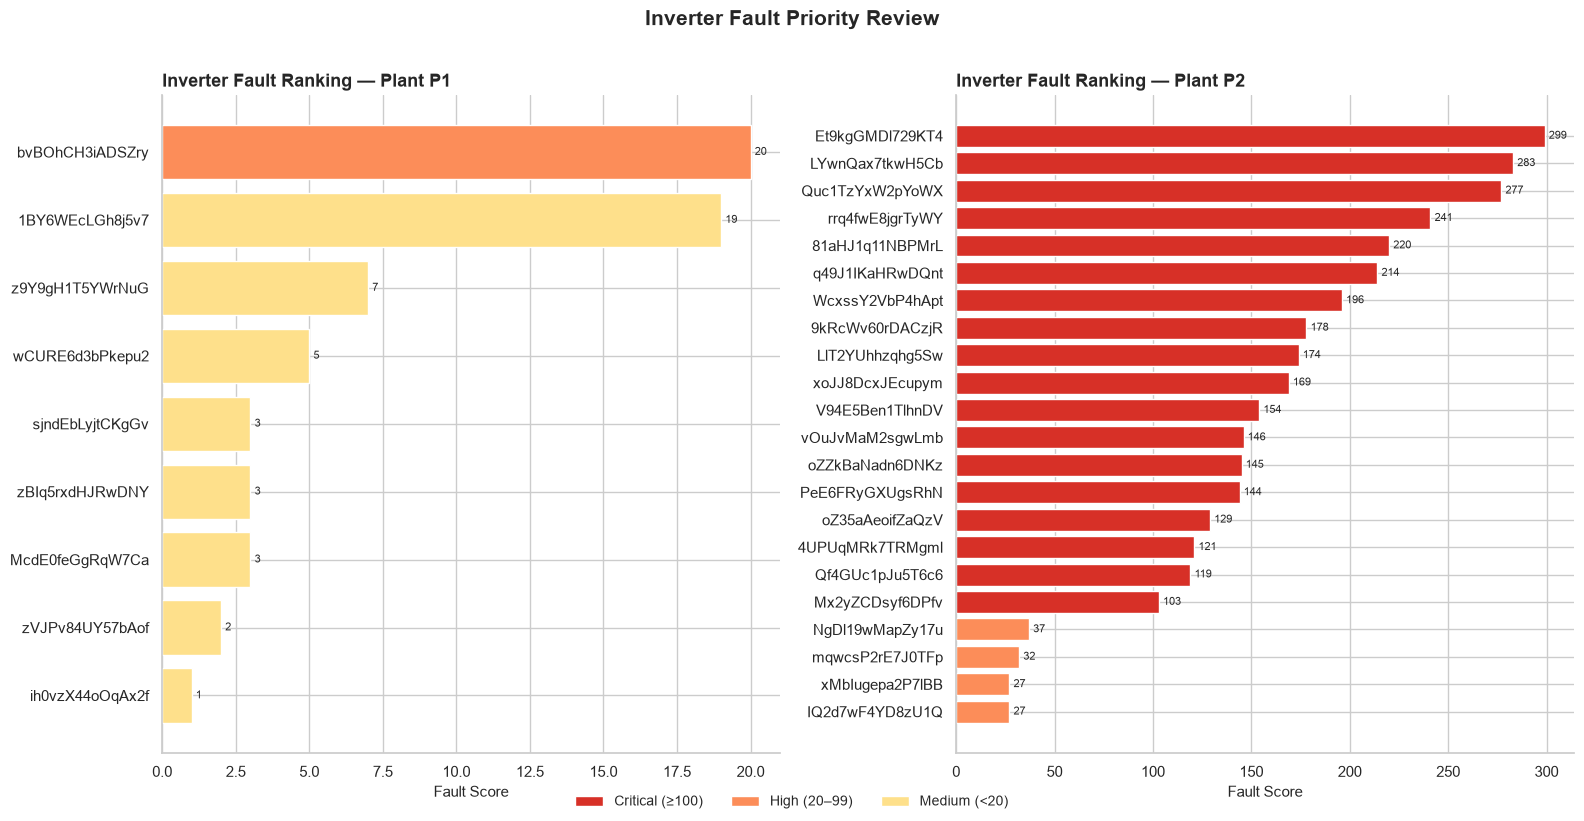

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, planta in zip(axes, ['p1', 'p2']):
    df_plot = ranking[ranking['id_planta'] == planta].sort_values('score_total')
    
    colors = ['#d73027' if s >= 100 else '#fc8d59' if s >= 20 else '#fee08b' 
              for s in df_plot['score_total']]
    
    bars = ax.barh(df_plot['id_inversor'], df_plot['score_total'], color=colors)
    ax.set_xlabel('Fault Score', fontsize=11)
    ax.set_title(f'Inverter Fault Ranking — Plant {planta.upper()}', fontsize=13, fontweight='bold', loc='left')
    ax.bar_label(bars, padding=3, fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

# Leyenda manual
legend_elements = [
    Patch(facecolor='#d73027', label='Critical (≥100)'),
    Patch(facecolor='#fc8d59', label='High (20–99)'),
    Patch(facecolor='#fee08b', label='Medium (<20)')
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=10, frameon=False)

plt.suptitle('Inverter Fault - Priority Review', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/graphics/inverter-fault-ranking.png', dpi=150, bbox_inches='tight')
plt.show()